# Load Example Images

In [1]:
import requests
from PIL import Image
from io import BytesIO
import os

# Output folder
output_folder = "/kaggle/working/"
os.makedirs(output_folder, exist_ok=True)

# Number of images
n = 9

for i in range(1, n + 1):
    url = "https://picsum.photos/300"

    res = requests.get(url)
    img = Image.open(BytesIO(res.content)).convert("RGB")

    save_path = os.path.join(output_folder, f"img{i}.jpg")
    img.save(save_path, "JPEG")

print("Saved 9 images from API to /kaggle/working/")

Saved 9 images from API to /kaggle/working/


# Main Code (Rafat's Area for Greyscale Color Palette)

## Grayscale Quantization Formula (Color Palette Reduction)

### Formula

$$
\text{new\_pixel} = \left\lfloor \frac{\text{pixel}}{256 / N} \right\rfloor \times \left(\frac{256}{N}\right)
$$

### Where

- **pixel**: Original pixel value (0–255)  
- **N**: Palette size (number of gray levels)  

---

### Example

For $N = 4$:

$$
\text{step} = \frac{256}{4} = 64
$$

Output values:
$$
0,\ 64,\ 128,\ 192
$$

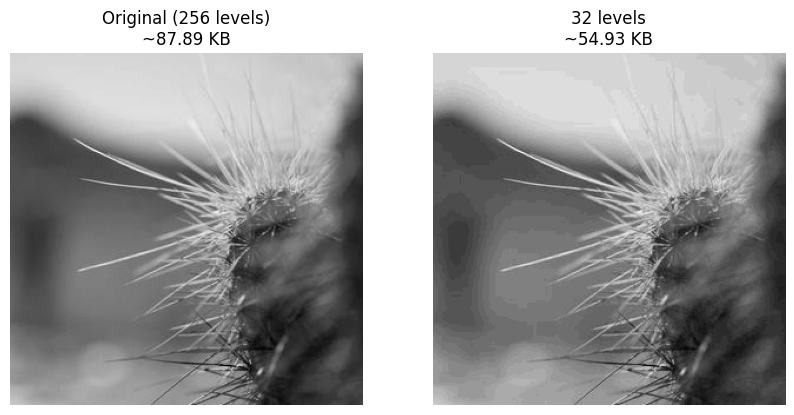

In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ===== INPUT =====
palette_size = 32

# Load image and convert to grayscale
img = Image.open('img1.jpg').convert('L')

# Convert to numpy array
img_np = np.array(img)

# Check palette size
if palette_size <= 0 or palette_size > 256:
    raise ValueError("Palette size must be between 1 and 256")

# Step size
step = 256 // palette_size

# Quantization
quantized_np = (img_np // step) * step

# ===== SIZE ESTIMATION (NO FILE SAVE) =====
h, w = img_np.shape

# Original: 8 bits per pixel
original_size_kb = (h * w * 8) / (8 * 1024)

# Quantized: log2(palette_size) bits per pixel
bits_per_pixel = int(np.log2(palette_size))
quantized_size_kb = (h * w * bits_per_pixel) / (8 * 1024)

# ===== DISPLAY =====
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_np, cmap='gray')
plt.title(f"Original (256 levels)\n~{original_size_kb:.2f} KB")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(quantized_np, cmap='gray')
plt.title(f"{palette_size} levels\n~{quantized_size_kb:.2f} KB")
plt.axis('off')

plt.show()

# Main Code (Pravesh's Area)